# Names: Zachary Houlton, Samuel Li, Ariv Mondal, Daniel Zhu

# Data Science Lab: Lab 1

Submit:

A read-only link to your colab notebook, executed and saved (so that we can run it, but don't necessarily have to, to see your results).

For any questions that require written explanation, please use Markdown - it is a lot easier for us to read than comments in the code.

**If you used any AI help, please describe how you used it and what you used.**

**Goals of this Lab:**
1.  Practice with Pandas, Numpy and Data Exploration.
2.  Download a more realistic data set and explore it!
3.  Training vs testing error
4.  (Optional) Review important results from probability, such as the CLT.


## AI Help
### Problem 1: N/A, mostly boilerplate code from class.
### Problem 2: Used Gemini to assist with syntax when identifying numerical and categorical features. Also used for making the histogram plots look organized.
### Problem 3: Used Gemini to help extract from the zip file, debug the relative frequency function, and identify which Pandas library functions to use such as .nunique() and .idxmax().
### Problem 4: Used Gemini for help with syntax in creating training vs testing score plot
### Problem 5: Used Gemini to help with syntax in finding total number of points per label using .flatten() and titling images in part 2.

In [ ]:
# Some useful libraries
import numpy as np
from numpy.random import default_rng

#Pandas for data structure and analysis tools
import pandas as pd

#seaborn and matplotlib for plotting
import seaborn as sns
import matplotlib.pyplot as plt

#for nice vector graphics
%matplotlib inline

#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('png', 'pdf')

np.random.seed(42) # Fixed seed for reproducibility
rng = default_rng(42)


# Problem 1

In class we explored the diabetes dataset using decision trees.

Part 1. load that data set again.

Part 2. Filter out any data points that missing data -- we did this just for data points that had missing BMI or Glucose values. How many data points did you end up filtering out?

Part 3: Figure out how to run logistic regression from ``sklearn``. Note that except for importing the right sklearn library, your code should adhere to our basic paradigm:
```
model = FamilyOfModels
model.fit(X,y)
model.predict(x)
```

Part 4: Report the accuracy of your model, by using the command ``model.predict`` just like we did for trees.

Part 5: Plot the decision boundary -- this should be a simple cut-and-paste from the code we used.

Bonus: do the same thing for XGBoost.

Part 1

In [ ]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

# Read in data
file_path = r'/content/drive/MyDrive/diabetes.csv'
diabetes_data = pd.read_csv(file_path)
diabetes_data.head()
diabetes_data.shape


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(768, 9)

Part 2

In [ ]:

# Remove invalid data points
filtered_data = diabetes_data[(diabetes_data['Glucose'] != 0) & (diabetes_data['BMI'] != 0) & (diabetes_data['BloodPressure'] != 0) & (diabetes_data['SkinThickness'] != 0) & (diabetes_data['Insulin'] != 0)]

original_count = diabetes_data.shape[0]
filtered_count = filtered_data.shape[0]
removed = original_count - filtered_count
X = filtered_data[['Glucose', 'BMI']].values
y = filtered_data['Outcome'].values

print(f"Data points removed: {removed}")

Data points removed: 376


Part 3

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train logistic regression model
model = LogisticRegression()
model.fit(X, y)


LogisticRegression()

Part 4

In [ ]:
# Predict y
y_prediction = model.predict(X)
accuracy = accuracy_score(y, y_prediction)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7729591836734694


Part 5

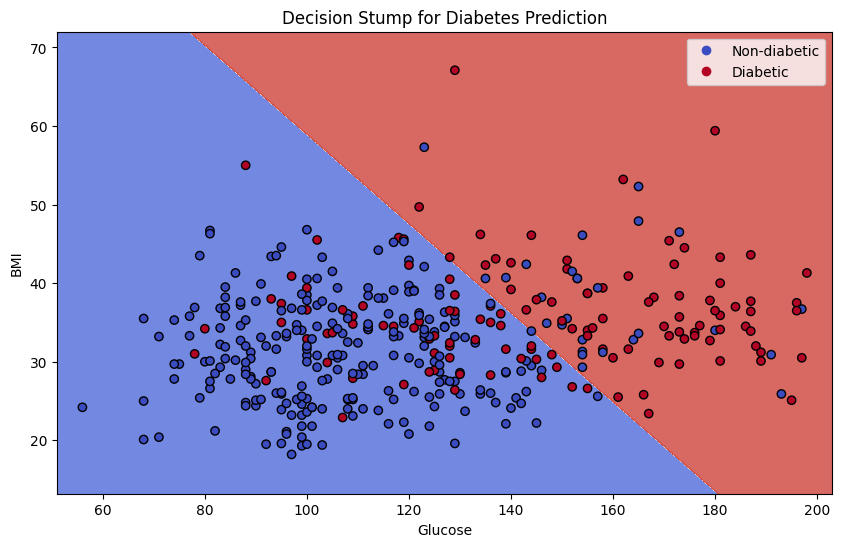

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Decision Stump for Diabetes Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non-diabetic', 'Diabetic'])
plt.show()

# Problem 2

Hospitals are penalized for avoidable 30-day readmissions. We're going to do some preliminary exploration of a data set that explores this topic.

The UCI Diabetes data set assembles a data set with over 100,000 data points, collecting data from 130-US hospitals, compiled over 10 years (1999–2008).

You can load this with the following commands (you may need to ``!pip install ucimlrepo``)
```
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=296)
X_uci = ds.data.features   # pandas DataFrame of features
y_uci  = ds.data.targets    # target(s), incl. readmitted
```

Part 1. How many data points and how many features does the above dataset have? How many of the features are ``numerical``, and how many are ``categorical``?

Part 2. Run the following pandas commands
```
y_uci.value_counts()
X_uci.head()
X_uci.info()
X_uci.describe()
X_uci.isna().sum()
X_uci.isna().mean()
```
and very briefly, say what each command is doing.

Part 3: How many missing values are there per column?  How many rows are complete, i.e., how many rows would survive if we removed each row that had at least one missing value?

Part 4: Plot histograms for each of the following columns:
* "time_in_hospital"
* "num_lab_procedures"
* "num_procedures"
* "num_medications"
* "number_outpatient"
* "number_emergency"
* "number_inpatient"
* "number_diagnoses"

There are many ways to plot a histogram. One way is using ``seaborn`` via the command
``sns.histplot(X_uci['age'].dropna(), bins=30, kde=False)``.

Part 5. (Optional) We're not going to do much more with this dataset, but it's a far richer and more complex dataset than our first Diabetes dataset. Feel free to try running decision trees, logistic regression, or anything else. If you do, I recommend you compare concepts such as **accuracy**, **balanced accuracy**, and **auc_roc** (we will be discussing these a little later).


Part 1

In [ ]:
!pip install ucimlrepo

In [ ]:
# Load the data
from ucimlrepo import fetch_ucirepo
ds = fetch_ucirepo(id=296)
X_uci = ds.data.features
y_uci  = ds.data.targets

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [ ]:
# Number of data points and features
num_data_points, num_features = X_uci.shape
print(f"Number of data points: {num_data_points}")
print(f"Total number of features: {num_features}")

# Identify numerical and categorical features
numerical_features = X_uci.select_dtypes(include=np.number).columns
categorical_features = X_uci.select_dtypes(include='object').columns

num_numerical = len(numerical_features)
num_categorical = len(categorical_features)

print(f"Number of numerical features: {num_numerical}")
print(f"Number of categorical features: {num_categorical}")

Number of data points: 101766
Total number of features: 47
Number of numerical features: 11
Number of categorical features: 36


Part 2

In [ ]:
display(y_uci.value_counts()) # Displays the distribution of the target colomn
display(X_uci.head()) # Returns the first 5 rows of the DataFrame
X_uci.info() # Prints a summary of the DataFrame
display(X_uci.describe()) # Generates statistics for each numerical feature
display(X_uci.isna().sum()) # Counts the number of missing values for each colomn
display(X_uci.isna().mean()) # Calculates the proportion of each column that has missing values

,count
readmitted,
NO,54864
>30,35545
<30,11357


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
payer_code,40256
medical_specialty,49949


,0
race,0.022336
gender,0.000000
age,0.000000
weight,0.968585
admission_type_id,0.000000
discharge_disposition_id,0.000000
admission_source_id,0.000000
time_in_hospital,0.000000
payer_code,0.395574
medical_specialty,0.490822


Part 3

In [ ]:
print("Missing values per column:")
display(X_uci.isna().sum())

cleaned_X_uci = X_uci.dropna()
complete_rows = cleaned_X_uci.shape[0]
print(f"Number of complete rows: {complete_rows}")

Missing values per column:


,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
payer_code,40256
medical_specialty,49949


Number of complete rows: 0


Part 4

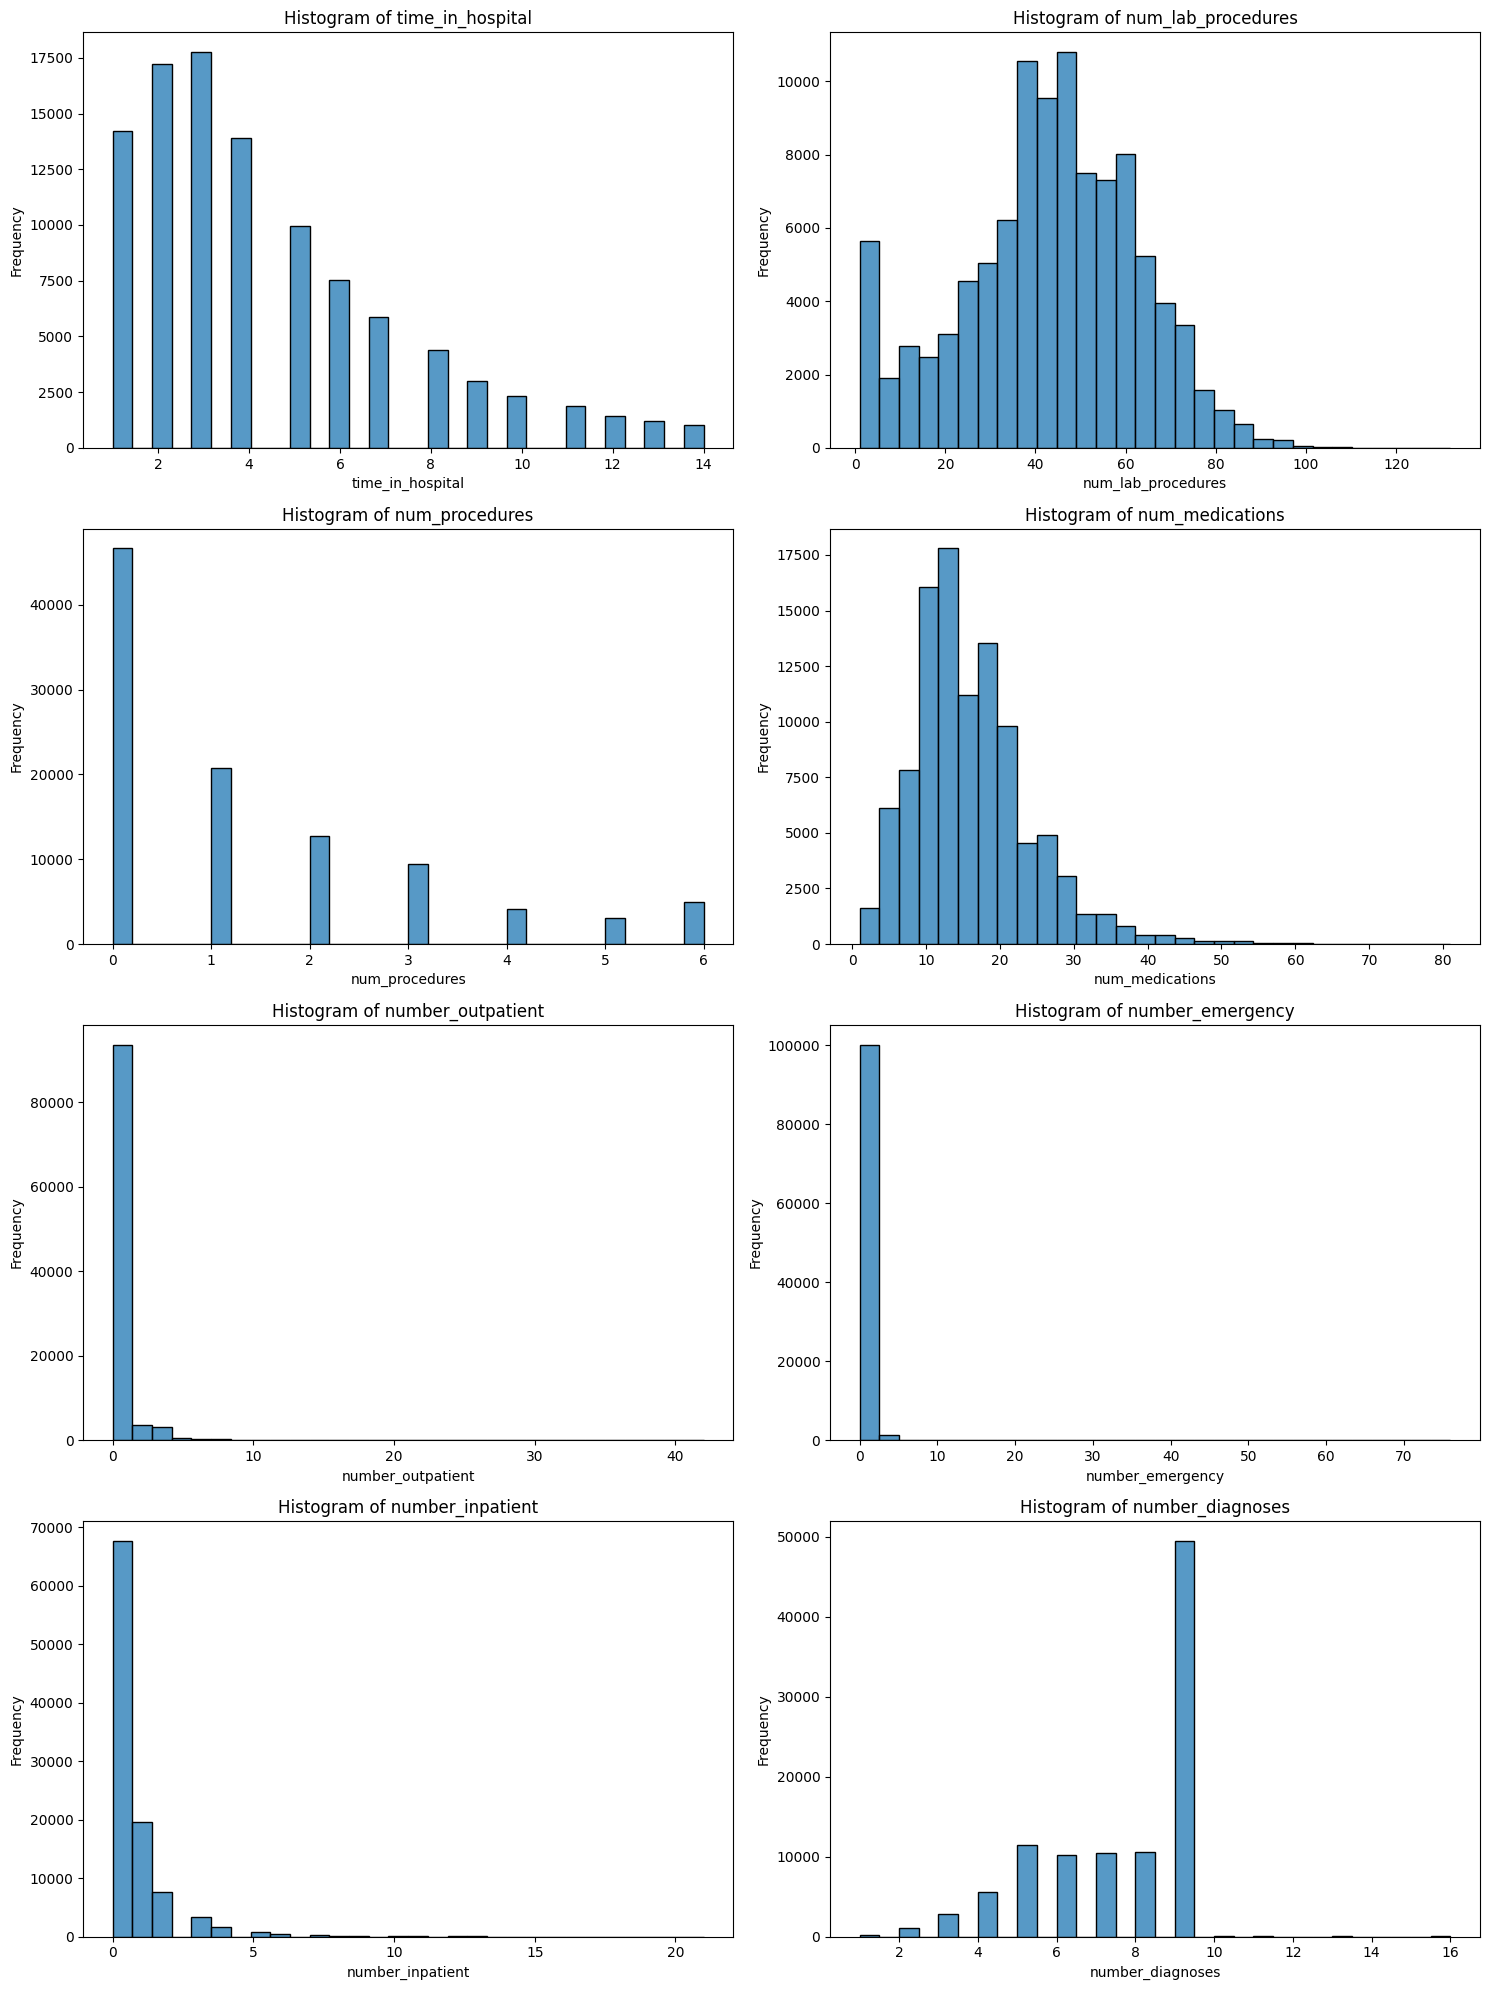

In [ ]:
columns_to_plot = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

plt.figure(figsize=(15, 20))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(4, 2, i)
    sns.histplot(X_uci[col].dropna(), bins=30, kde=False)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Problem 3

The goal of this exercise is for you to get more experience with Pandas, and to get a chance to explore a cool data set.  Download the file Names.zip from Canvas.  This contains the frequency of all names that appeared more than 5 times on a social security application from 1880 through 2015.

Part 1. Write a program that on input $k$ and XXXX, returns the top $k$ names from year XXXX.

Part 2. Write a program that on input Name returns the frequency for men and women of the name Name.

Part 3. It could be that names are more diverse now than they were in 1880, so that a name may be relatively the most popular, though its frequency may have been decreasing over the years.  Modify the above to return the relative frequency.

Part 4. Find all the names that used to be more popular for one gender, but then became more popular for another gender.

•(Optional) Find something cool about this data set.

Part 1

In [ ]:
# Load and unzip the data
import os
import zipfile

zip_file_path = '/content/drive/MyDrive/Names.zip'
extract_dir = './names_data'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.listdir(os.path.join(extract_dir, 'Names'))[:5])

['yob1912.txt', 'yob1969.txt', 'yob1936.txt', 'yob1897.txt', 'yob1913.txt']


In [ ]:
# Define columns
columns = ['Name', 'Gender', 'Count']
all_names = []
names_dir = os.path.join(extract_dir, 'Names')

# Iterate through each file and extract the year
for file_name in os.listdir(names_dir):
      year = int(file_name[3:7])
      file_path = os.path.join(names_dir, file_name)

      df = pd.read_csv(file_path, names=columns)
      df['Year'] = year
      all_names.append(df)

# Concatenate all dfs into one large one
names_df = pd.concat(all_names, ignore_index=True)

print("Shape: ", names_df.shape)
display(names_df.head())

Shape:  (1858689, 4)


,Name,Gender,Count,Year
0,Mary,F,32303,1912
1,Helen,F,16133,1912
2,Dorothy,F,12645,1912
3,Margaret,F,12535,1912
4,Ruth,F,11280,1912


In [ ]:
def get_top_k_names(k: int, year: int):
    year_data = names_df[names_df['Year'] == year]

    # Sort in descending order and return the first k
    top_k_names = year_data.sort_values(by='Count', ascending=False).head(k)

    return top_k_names

# Testing
print("Top 5 names in 2000:")
display(get_top_k_names(5, 2000))

Top 5 names in 2000:


,Name,Gender,Count,Year
1309892,Jacob,M,34467,2000
1309893,Michael,M,32028,2000
1309894,Matthew,M,28572,2000
1309895,Joshua,M,27534,2000
1292239,Emily,F,25953,2000


Part 2

In [ ]:
def get_name_frequency(name: str):
    name_data = names_df[names_df['Name'].str.lower() == name.lower()]
    if name_data.empty:
        print(f"Name '{name}' not in the dataset.")
        return pd.DataFrame(columns=['Name', 'Gender', 'Count'])

    # Group by gender and sum the counts
    frequency_by_gender = name_data.groupby(['Name', 'Gender'])['Count'].sum().reset_index()
    return frequency_by_gender

# Testing
print("Frequency for Samuel:")
display(get_name_frequency('Samuel'))


Frequency for Samuel:


,Name,Gender,Count
0,Samuel,F,2781
1,Samuel,M,728815


Part 3

In [ ]:
# Calculate total births per year and gender
total_yearly_gender_counts = names_df.groupby(['Year', 'Gender'])['Count'].sum().reset_index()
total_yearly_gender_counts.rename(columns={'Count': 'Total_Gender_Count'}, inplace=True)
display(total_yearly_gender_counts.head())

,Year,Gender,Total_Gender_Count
0,1880,F,90992
1,1880,M,110490
2,1881,F,91953
3,1881,M,100743
4,1882,F,107848


In [ ]:
def get_name_relative_frequency(name: str):
    name_data = names_df[names_df['Name'].str.lower() == name.lower()].copy()
    if name_data.empty:
        print(f"Name '{name}' not in the dataset.")
        return pd.DataFrame(columns=['Name', 'Gender', 'Year', 'Count', 'Relative_Frequency'])

    # Merge with total yearly gender counts to calculate relative frequency
    merged_data = pd.merge(
        name_data,
        total_yearly_gender_counts,
        on=['Year', 'Gender'],
        how='left'
    )

    # Calculate relative frequency
    merged_data['Relative_Frequency'] = merged_data['Count'] / merged_data['Total_Gender_Count']

    # Drop the intermediate total count column
    merged_data.drop(columns=['Total_Gender_Count'], inplace=True)

    return merged_data.sort_values(by=['Year', 'Gender']).reset_index(drop=True)

# Testing
print("Relative frequency for Zachary:")
display(get_name_relative_frequency('Zachary'))

Relative frequency for Zachary:


,Name,Gender,Count,Year,Relative_Frequency
0,Zachary,M,6,1900,0.000040
1,Zachary,M,8,1912,0.000019
2,Zachary,M,18,1913,0.000035
3,Zachary,M,11,1914,0.000017
4,Zachary,M,14,1915,0.000016
...,...,...,...,...,...
146,Zachary,M,5738,2013,0.003046
147,Zachary,F,7,2014,0.000004
148,Zachary,M,5162,2014,0.002701
149,Zachary,F,5,2015,0.000003


Part 4

In [ ]:
# Calculate relative frequency for all names across all years and genders
names_with_relative_frequency = pd.merge(
    names_df,
    total_yearly_gender_counts,
    on=['Year', 'Gender'],
    how='left'
)
names_with_relative_frequency['Relative_Frequency'] = names_with_relative_frequency['Count'] / names_with_relative_frequency['Total_Gender_Count']
names_with_relative_frequency.drop(columns=['Total_Gender_Count'], inplace=True)
display(names_with_relative_frequency.head())

,Name,Gender,Count,Year,Relative_Frequency
0,Mary,F,32303,1912,0.057879
1,Helen,F,16133,1912,0.028906
2,Dorothy,F,12645,1912,0.022657
3,Margaret,F,12535,1912,0.022460
4,Ruth,F,11280,1912,0.020211


In [ ]:
# Determine the dominant gender per name per year
yearly_dominant_gender = names_with_relative_frequency.loc[names_with_relative_frequency.groupby(['Year', 'Name'])['Relative_Frequency'].idxmax()]
yearly_dominant_gender = yearly_dominant_gender[['Name', 'Year', 'Gender', 'Relative_Frequency']]
display(yearly_dominant_gender.head())

,Name,Year,Gender,Relative_Frequency
1544503,Aaron,1880,M,0.000923
1545281,Ab,1880,M,0.000045
1543608,Abbie,1880,F,0.000780
1545282,Abbott,1880,M,0.000045
1544168,Abby,1880,F,0.000066


In [ ]:
# Find all names that have flipped genders over the years
gender_flipping_names = yearly_dominant_gender.groupby('Name')['Gender'].nunique()
gender_flipping_names = gender_flipping_names[gender_flipping_names > 1].index.tolist()

# Filter the df to show only the names that flipped
flipped_names_data = yearly_dominant_gender[yearly_dominant_gender['Name'].isin(gender_flipping_names)]

# Sort by name and year
flipped_names_data = flipped_names_data.sort_values(by=['Name', 'Year'])

print(f"Found {len(gender_flipping_names)} names that have changed gender.")
display(gender_flipping_names)

Found 5070 names that have changed gender.


['Aalijah',
 'Aamari',
 'Aaren',
 'Aareon',
 'Aari',
 'Aarian',
 'Aarin',
 'Aarion',
 'Aaris',
 'Aarya',
 'Aaryn',
 'Aavyn',
 'Aba',
 'Abba',
 'Abbey',
 'Abell',
 'Abey',
 'Abie',
 'Abijah',
 'Abimbola',
 'Abiola',
 'Abir',
 'Abishai',
 'Abiyah',
 'Abney',
 'Abrar',
 'Abraxas',
 'Abrian',
 'Abriel',
 'Aby',
 'Abyan',
 'Acea',
 'Acelin',
 'Acey',
 'Acie',
 'Acy',
 'Adair',
 'Adali',
 'Adalid',
 'Adama',
 'Adar',
 'Adason',
 'Addington',
 'Addis',
 'Addison',
 'Adean',
 'Adebola',
 'Adel',
 'Adell',
 'Adeyinka',
 'Adgie',
 'Adi',
 'Adie',
 'Adis',
 'Adisa',
 'Adison',
 'Adlai',
 'Adley',
 'Admire',
 'Adna',
 'Adonai',
 'Adoniah',
 'Adraine',
 'Adrean',
 'Adriann',
 'Adrien',
 'Adrienn',
 'Adrin',
 'Adrine',
 'Adryan',
 'Adryn',
 'Adyn',
 'Aeon',
 'Aerion',
 'Aeron',
 'Afsheen',
 'Afton',
 'Agam',
 'Agape',
 'Ah',
 'Ahmari',
 'Ahmi',
 'Aideen',
 'Aidyn',
 'Aidynn',
 'Aijalon',
 'Aiman',
 'Aimar',
 'Aime',
 'Aimen',
 'Ainsley',
 'Airen',
 'Aireon',
 'Aires',
 'Airin',
 'Airon',
 'Aivan',
 

# Problem 4

We looked at the MNIST data set in class (see the notebook in ``pages`` in Canvas). Recall that MNIST is a data set of handwritten digits. It is considered one of the ``easiest'' image recognition problems in computer vision, and we will see it again.

This exercise is simple exercise, and an opportunity to play around with this data set.

**Parts 1 to 7: Nothing to submit!** just run through the notebook we saw in class and try to make sure you understand all the commands.

Part 1. Make sure you can run through the entire Colab notebook posted. Especially if you haven't used Python, try to understand what every line is doing.

Part 2. How many data points are there, how many features are there, and what do the features represent?

Part 3. Compute how many times each digit appears in the dataset.

Part 4. Read the documentation for sklearn.model_selection.train_test_split and explain what this does.

Part 5. Read the documentation for DecisionTreeClassifier, and explain what score means.

Part 6. What happens to the **training score** as you increase the depth of the tree? Explain.

Part 7. What happens to the difference between **training score** and **testing score** as you increase the depth of the tree? Explain.

**Only submit your answer to this part**

Part 8. Fix the depth of the tree. For this example, use depth=6 (nothing special about the number 6, just to illustrate the concept). Then plot the difference of training score - testing score when you train on: 100, 500, 5000, 10000, 20,0000, 60,000 training points, always computing testing score by evaluating on the 10,000 testing points. Plot this trend.  Try to explain what you are seeing.  


In [ ]:
import numpy as np
from torchvision import datasets, transforms

# Custom transform to convert tensor to numpy array and remove channel dimension
class ToNumpyNoChannel:
    def __call__(self, tensor):
        return tensor.squeeze(0).numpy()  # Remove channel dimension (C, H, W -> H, W)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL image to PyTorch tensor
    transforms.Normalize(mean=(0.5,), std=(0.5,)),  # Normalize to [-1, 1]
    ToNumpyNoChannel()  # Convert tensor to numpy array and remove channel dimension
])

# Load datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Access data and labels as NumPy arrays
X_train = np.array([train_dataset[i][0] for i in range(len(train_dataset))])  # Features
y_train = np.array([train_dataset[i][1] for i in range(len(train_dataset))])  # Labels
X_test = np.array([test_dataset[i][0] for i in range(len(test_dataset))])    # Features
y_test = np.array([test_dataset[i][1] for i in range(len(test_dataset))])    # Labels

In [ ]:
import time
from sklearn.utils import check_random_state

t0 = time.time()
random_state = check_random_state(0)
permutation = random_state.permutation(X_train.shape[0])
X_train = X_train[permutation]
y_train = y_train[permutation]
permutation = random_state.permutation(X_test.shape[0])
X_test = X_test[permutation]
y_test = y_test[permutation]

In [ ]:
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

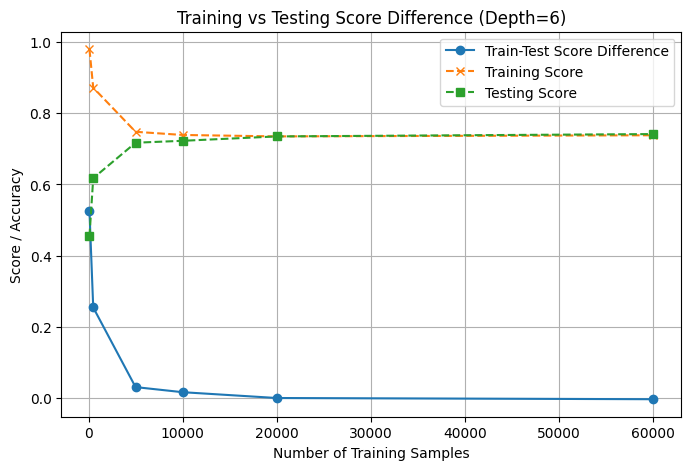

In [ ]:
# Part 8: Plot training score - testing score for different training set sizes (depth=6)
import matplotlib.pyplot as plt
from sklearn import tree

train_sizes = [100, 500, 5000, 10000, 20000, 60000]
diff_scores = []
training_scores = []
testing_scores = []

for train_samples in train_sizes:
    # Select subset for training
    X_train_subset = X_train[:train_samples]
    y_train_subset = y_train[:train_samples]
    dt = tree.DecisionTreeClassifier(max_depth=6, criterion='gini')
    dt.fit(X_train_subset, y_train_subset)
    train_score = dt.score(X_train_subset, y_train_subset)
    test_score = dt.score(X_test, y_test)
    training_scores.append(train_score)
    testing_scores.append(test_score)
    diff_scores.append(train_score - test_score)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, diff_scores, marker='o', label='Train-Test Score Difference')
plt.plot(train_sizes, training_scores, marker='x', linestyle='--', label='Training Score')
plt.plot(train_sizes, testing_scores, marker='s', linestyle='--', label='Testing Score')
plt.xlabel('Number of Training Samples')
plt.ylabel('Score / Accuracy')
plt.title('Training vs Testing Score Difference (Depth=6)')
plt.legend()
plt.grid(True)
plt.show()

With 100 training points, the plot shows that the model had significant overfitting with a training - testing accuracy difference of over 0.5. In general as the training size increases, the model becomes more generalized and less prone to overfitting. At 20000 and 60000 training points, the difference between training and testing accuracies converged very closely to 0.

# Problem 5

We now turn to a somewhat more sophisticated data set: CIFAR10.

Load the data using:
```
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
```

Part 1. How many data points are there, and how many labels? How many points for each label?

Part 2. Figure out how to display some of the images from CIFAR10.

Part 3: Reshape X_train into a matrix X_tr so that each row is a data point.
 What are the dimensions of X_train?

Part 4: Generate decision trees of depth 1 to 15, and for each, compute the training accuracy and the testing accuracy.

If you did this correctly and ran the notebook, you noticed that CIFAR10 indeed looks like a ``harder'' problem. Deep trees are again doing very well on the training set, and they do a little better than guessing on the testing data, but not as well as they do on MNIST. We will revisit CIFAR10 several times, as we develop more powerful tools. And we will see that we will do much better than deep decision trees!

In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Part 1

In [ ]:
total_data_points = len(X_train) + len(X_test)
print(f"Total number of data points: {total_data_points}")

num_labels = len(labels)
print(f"Total number of labels: {num_labels}")

# Count points for each label in training set
train_label_counts = pd.Series(y_train.flatten()).value_counts().sort_index()
test_label_counts = pd.Series(y_test.flatten()).value_counts().sort_index()
print("Total points for each label:")
for i, label_name in enumerate(labels):
    total_count = train_label_counts.get(i, 0) + test_label_counts.get(i, 0)
    print(f"  {label_name}: {total_count}")

Total number of data points: 60000
Total number of labels: 10
Total points for each label:
  airplane: 6000
  automobile: 6000
  bird: 6000
  cat: 6000
  deer: 6000
  dog: 6000
  frog: 6000
  horse: 6000
  ship: 6000
  truck: 6000


Part 2

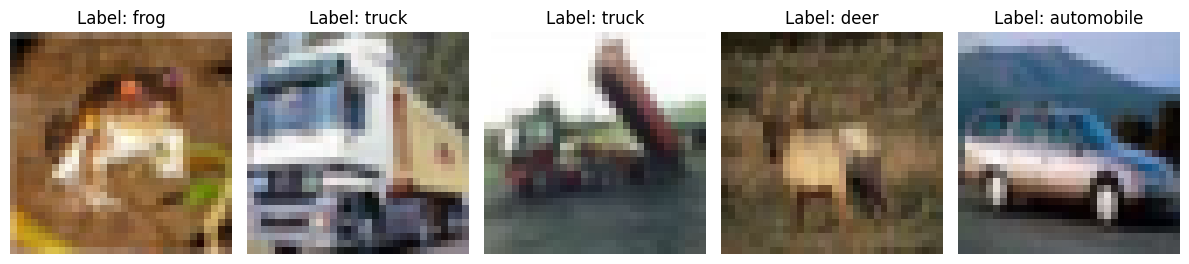

In [ ]:
# Display the first 5 images
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {labels[y_train[i][0]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Part 3

In [ ]:
num_samples = X_train.shape[0]
image_size = X_train.shape[1] * X_train.shape[2] * X_train.shape[3]
X_tr = X_train.reshape(num_samples, image_size)

print(f"Dimension of X_tr: {X_tr.shape}")

Dimension of X_tr: (50000, 3072)


Part 4

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Flatten X_test and y
num_test_samples = X_test.shape[0]
X_te = X_test.reshape(num_test_samples, image_size)
y_tr = y_train.flatten()
y_te = y_test.flatten()

training_accuracies = []
testing_accuracies = []
depths = range(1, 16)

for depth in depths:
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_classifier.fit(X_tr, y_tr)

    # Predict and calculate accuracy
    y_train_pred = dt_classifier.predict(X_tr)
    train_acc = accuracy_score(y_tr, y_train_pred)
    training_accuracies.append(train_acc)

    # Predict on testing data and calculate accuracy
    y_test_pred = dt_classifier.predict(X_te)
    test_acc = accuracy_score(y_te, y_test_pred)
    testing_accuracies.append(test_acc)

    print(f"Depth: {depth}, Training Accuracy: {train_acc:.4f}, Testing Accuracy: {test_acc:.4f}")

Depth: 1, Training Accuracy: 0.1570, Testing Accuracy: 0.1570
Depth: 2, Training Accuracy: 0.1927, Testing Accuracy: 0.1955
Depth: 3, Training Accuracy: 0.2376, Testing Accuracy: 0.2394
Depth: 4, Training Accuracy: 0.2571, Testing Accuracy: 0.2527
Depth: 5, Training Accuracy: 0.2676, Testing Accuracy: 0.2669
Depth: 6, Training Accuracy: 0.2959, Testing Accuracy: 0.2812
Depth: 7, Training Accuracy: 0.3223, Testing Accuracy: 0.2929
Depth: 8, Training Accuracy: 0.3496, Testing Accuracy: 0.3025
Depth: 9, Training Accuracy: 0.3828, Testing Accuracy: 0.3040
Depth: 10, Training Accuracy: 0.4264, Testing Accuracy: 0.3054
Depth: 11, Training Accuracy: 0.4790, Testing Accuracy: 0.3025
Depth: 12, Training Accuracy: 0.5369, Testing Accuracy: 0.3030
Depth: 13, Training Accuracy: 0.6015, Testing Accuracy: 0.2954
Depth: 14, Training Accuracy: 0.6644, Testing Accuracy: 0.2921
Depth: 15, Training Accuracy: 0.7270, Testing Accuracy: 0.2873


The gap increases as we increase the depth of the tree due to overfitting.

# The next two problems are optional, but recommended

We will be generating lots of random data sets in this class, in order to test the behavior of machine learning algorithms.

So it's useful to know how to generate random data, and display it.

# Problem 6 (Optional, recommended)

**Part 1.** Generate 1,000 samples of 2 dimensional data from the Gaussian distribution $\left(\begin{array}{cc}X_{i}\\Y_{i}\end{array}\right)∼N\biggl(\left(\begin{array}{cc}-5\\5\end{array}\right),\left(\begin{array}{cc}2 & 0.8\\0.8 & 3\end{array}\right)\biggr)$.

**Part 2.** Plot these points.

**Part 3.** Find the Eigenvectors and Eigenvalues of the covariance matrix using np.linalg.eig, or np.linalg.eigh, or something else of your choice.

**Part 4.** Now take the 1,000 points you generated in the first part, and use them to estimate the mean and covariance matrix for this multi-dimensional data using elementary numpy commands, i.e., addition, multiplication, division (do not use a command that takes data and returns the mean or standard deviation).

*Remark*: If you did this correctly: You should have made a number of observations. (i) The points you plotted should look like an elongated ellipse. (ii) The axis of elongation (the major axis of the ellipse) should be aligned with the eigenvector you computed that has the largest eigenvalue. The minor axis, should be aligned with the other eigenvector you computed. (iii) In the last part, you computed what is called the *empirical covariance* matrix. This should be quite close to the covariance matrix you used to generate the data. If we used more and more points (10,000, 100,000, etc.), then our empirical estimate would look more and more like what we used to generate the data.


# Problem 7: Central Limit Theorem (Optional, recommended)

Back in EE351K you learned the Law of Large Numbers, and the Central Limit Theorem, among many other things. The Law of Large Numbers says that if $X_i$ are independent and identically distributed (iid) random variables, then $(1/N) \sum X_i$ converges to $\mathbb{E}[X]$. That's the law of large numbers.

You also learned the Central Limit Theorem. This says that if $X_i$ are zero mean, have variance 1, and are iid, then $(1/\sqrt{N}) \sum X_i$ converges to a random variable. Which random variable? A standard (zero mean, unit variance) Gaussian.

We're going to check the central limit theorem empirically, as an excuse to do more practice with Python and numpy and basic plotting.

Let $X_i$ be an iid Bernoulli random variable with value \{-1,1\}. Look at the random variable
$Z_n = \frac{1}{\sqrt{n}}\sum X_i$. By taking 1000 samples from $Z_n$, plot its histogram. **Note**: To generate 1,000 samples from $Z_n$, you need to generate $1,000 \times n$ samples of $X_i$, since each $Z$ needs $1,000$ $X_i$'s. Now check that for small $n$ (set $n= 5$) $Z_n$ does not look that much like a Gaussian, but when $n$ is bigger (set $n = 50$) it looks much more like a Gaussian. Check also for much bigger $n$: $n = 250$, to see that at this point, one can really see the bell curve.